# Hyperparameter Experiment: Number of Categories

**Assignment 5 – Convolutional Neural Networks**  
**Hyperparameter:** Number of categories

## Approach and Assumptions

### Hyperparameter
The hyperparameter under investigation is the **number of gesture categories** used during training and evaluation. The number of categories directly affects both the complexity of the classification task and the structure of the model's output layer (number of softmax neurons).

### Values tested
We test **2, 3, 4, and 5 categories**, using the following subsets of the HaGRID dataset sample:
- 2 categories: `like`, `stop`
- 3 categories: `like`, `stop`, `peace`
- 4 categories: `like`, `stop`, `peace`, `rock`
- 5 categories: `like`, `stop`, `peace`, `rock`, `fist`

### Hypotheses
1. **Accuracy will decrease** as the number of categories increases. With more classes the network must learn to distinguish more fine-grained differences between gestures, making the problem harder.
2. **Inference time will stay roughly constant** across different category counts. The forward pass is dominated by the convolutional layers; the final Dense layer changes only minimally with additional output neurons.
3. **Training time will increase** slightly with more categories, because the dataset grows (more images loaded) and the loss landscape becomes more complex.

### Controlled variables
All other hyperparameters are kept fixed to isolate the effect of the number of categories:
- Image size: 64×64 px, color (3 channels)
- Batch size: 8
- Max epochs: 50 (with early stopping, patience=3)
- Optimizer: Adam
- Model architecture: same CNN for all experiments

In [1]:
import cv2
import json
import time
from matplotlib import pyplot as plt
import numpy as np
import os
import random

from keras.models import Sequential
from keras.layers import (
    Input, Dense, Dropout, Flatten,
    Conv2D, MaxPooling2D,
    RandomFlip, RandomContrast
)
from keras.metrics import categorical_crossentropy
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.utils import to_categorical

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Fixed hyperparameters ────────────────────────────────────────────────────
IMG_SIZE      = 64
SIZE          = (IMG_SIZE, IMG_SIZE)
COLOR_CHANNELS = 3
BATCH_SIZE    = 8
EPOCHS        = 50
PATH          = '/Users/arne/Downloads/gesture_dataset_sample'

# ── Experiment values ────────────────────────────────────────────────────────
# Available categories in the dataset: like, stop, peace, rock, fist, dislike, ok, one, three, two_up
# no_gesture does not exist in this sample — replaced with 'fist'
ALL_CONDITIONS  = ['like', 'stop', 'peace', 'rock', 'fist']
CATEGORY_COUNTS = [2, 3, 4, 5]   # the four values we test

In [3]:
# ── Helper: pre-process a single image ──────────────────────────────────────
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.resize(img, SIZE)


# ── Helper: load images + labels for a given list of conditions ──────────────
def load_data(conditions, path):
    annotations = {}
    for cond in conditions:
        with open(f'{path}/_annotations/{cond}.json') as f:
            annotations[cond] = json.load(f)

    images, labels = [], []

    for condition in conditions:
        for filename in tqdm(os.listdir(f'{path}/{condition}'), desc=condition):
            uid = filename.split('.')[0]
            img = cv2.imread(f'{path}/{condition}/{filename}')
            if img is None:
                continue
            try:
                annotation = annotations[condition][uid]
            except KeyError:
                continue

            for i, bbox in enumerate(annotation['bboxes']):
                label = annotation['labels'][i]
                # skip any bbox whose label is not one of our target categories
                if label not in conditions:
                    continue

                x1 = int(bbox[0] * img.shape[1])
                y1 = int(bbox[1] * img.shape[0])
                w  = int(bbox[2] * img.shape[1])
                h  = int(bbox[3] * img.shape[0])
                crop = img[y1:y1+h, x1:x1+w]
                if crop.size == 0:
                    continue
                preprocessed = preprocess_image(crop)

                images.append(preprocessed)
                labels.append(conditions.index(label))

    return images, labels, conditions


# ── Helper: build CNN model ──────────────────────────────────────────────────
def build_model(num_classes):
    model = Sequential([
        RandomFlip('horizontal'),
        RandomContrast(0.1),

        Conv2D(64, (9, 9), activation='leaky_relu',
               input_shape=(IMG_SIZE, IMG_SIZE, COLOR_CHANNELS), padding='same'),
        MaxPooling2D((4, 4), padding='same'),

        Conv2D(32, (5, 5), activation='leaky_relu', padding='same'),
        MaxPooling2D((3, 3), padding='same'),

        Conv2D(32, (3, 3), activation='leaky_relu', padding='same'),
        MaxPooling2D((2, 2), padding='same'),

        Dropout(0.2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax'),
    ])
    model.compile(loss=categorical_crossentropy,
                  optimizer='adam', metrics=['accuracy'])
    return model

## Experiment Loop

For each category count we:
1. Load and split the data
2. Build a fresh model
3. Train with early stopping
4. Record test accuracy, test loss, training time, and inference time

In [4]:
results = []

for n_cats in CATEGORY_COUNTS:
    conditions = ALL_CONDITIONS[:n_cats]
    print(f"\n{'='*60}")
    print(f"Training with {n_cats} categories: {conditions}")
    print('='*60)

    # 1. Load data
    images, labels, label_names = load_data(conditions, PATH)
    print(f"  Total samples: {len(images)}")

    # 2. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=0.2, random_state=42
    )

    # 3. Normalise and reshape
    X_train = np.array(X_train).astype('float32') / 255.
    X_test  = np.array(X_test).astype('float32')  / 255.
    X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
    X_test  = X_test.reshape(-1,  IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

    y_train_oh = to_categorical(y_train, num_classes=n_cats)
    y_test_oh  = to_categorical(y_test,  num_classes=n_cats)

    # 4. Build and train
    model = build_model(n_cats)

    reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                    patience=2, min_lr=0.0001)
    stop_early  = EarlyStopping(monitor='val_loss', patience=3)

    t0 = time.time()
    history = model.fit(
        X_train, y_train_oh,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1,
        validation_data=(X_test, y_test_oh),
        callbacks=[reduce_lr, stop_early]
    )
    train_time = time.time() - t0

    # 5. Evaluate accuracy
    test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)

    # 6. Measure inference time (average over 100 single-sample predictions)
    sample = X_test[:1]
    _ = model.predict(sample, verbose=0)   # warm-up
    t0 = time.time()
    for _ in range(100):
        model.predict(sample, verbose=0)
    inf_time_ms = (time.time() - t0) / 100 * 1000

    results.append({
        'n_categories':    n_cats,
        'conditions':      conditions,
        'test_accuracy':   test_acc,
        'test_loss':       test_loss,
        'train_time_s':    train_time,
        'inf_time_ms':     inf_time_ms,
        'epochs_trained':  len(history.history['loss']),
        'history':         history.history,
    })

    print(f"  Test accuracy:   {test_acc:.4f}")
    print(f"  Inference time:  {inf_time_ms:.2f} ms")
    print(f"  Training time:   {train_time:.1f} s  ({len(history.history['loss'])} epochs)")


Training with 2 categories: ['like', 'stop']


like:   0%|          | 0/250 [00:00<?, ?it/s]

like:   2%|▏         | 5/250 [00:00<00:05, 44.86it/s]

like:   5%|▍         | 12/250 [00:00<00:04, 54.18it/s]

like:   7%|▋         | 18/250 [00:00<00:04, 52.30it/s]

...

121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9829 - loss: 0.0428

123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9830 - loss: 0.0427

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9831 - loss: 0.0426

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9890 - loss: 0.0363 - val_accuracy: 0.9360 - val_loss: 0.2682 - learning_rate: 1.0000e-04


  Test accuracy:   0.9360
  Inference time:  32.61 ms
  Training time:   95.9 s  (26 epochs)


## Results Visualization

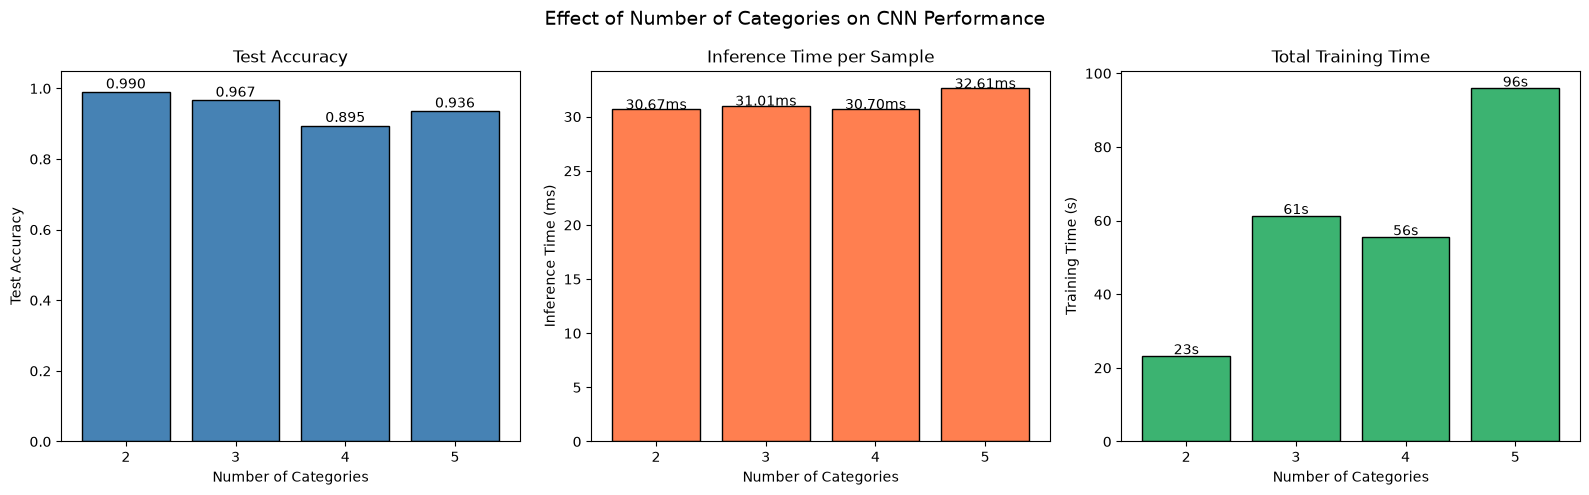

In [5]:
n_cats_list  = [r['n_categories']  for r in results]
accuracies   = [r['test_accuracy'] for r in results]
inf_times    = [r['inf_time_ms']   for r in results]
train_times  = [r['train_time_s']  for r in results]
epochs_list  = [r['epochs_trained'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Effect of Number of Categories on CNN Performance', fontsize=14)

# ── Plot 1: Test Accuracy ────────────────────────────────────────────────────
axes[0].bar(n_cats_list, accuracies, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Categories')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy')
axes[0].set_xticks(n_cats_list)
axes[0].set_ylim(0, 1.05)
for x, y in zip(n_cats_list, accuracies):
    axes[0].text(x, y + 0.01, f'{y:.3f}', ha='center', fontsize=10)

# ── Plot 2: Inference Time ───────────────────────────────────────────────────
axes[1].bar(n_cats_list, inf_times, color='coral', edgecolor='black')
axes[1].set_xlabel('Number of Categories')
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Inference Time per Sample')
axes[1].set_xticks(n_cats_list)
for x, y in zip(n_cats_list, inf_times):
    axes[1].text(x, y + 0.01, f'{y:.2f}ms', ha='center', fontsize=10)

# ── Plot 3: Training Time ────────────────────────────────────────────────────
axes[2].bar(n_cats_list, train_times, color='mediumseagreen', edgecolor='black')
axes[2].set_xlabel('Number of Categories')
axes[2].set_ylabel('Training Time (s)')
axes[2].set_title('Total Training Time')
axes[2].set_xticks(n_cats_list)
for x, y in zip(n_cats_list, train_times):
    axes[2].text(x, y + 0.5, f'{y:.0f}s', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('results_overview.png', dpi=120)
plt.show()

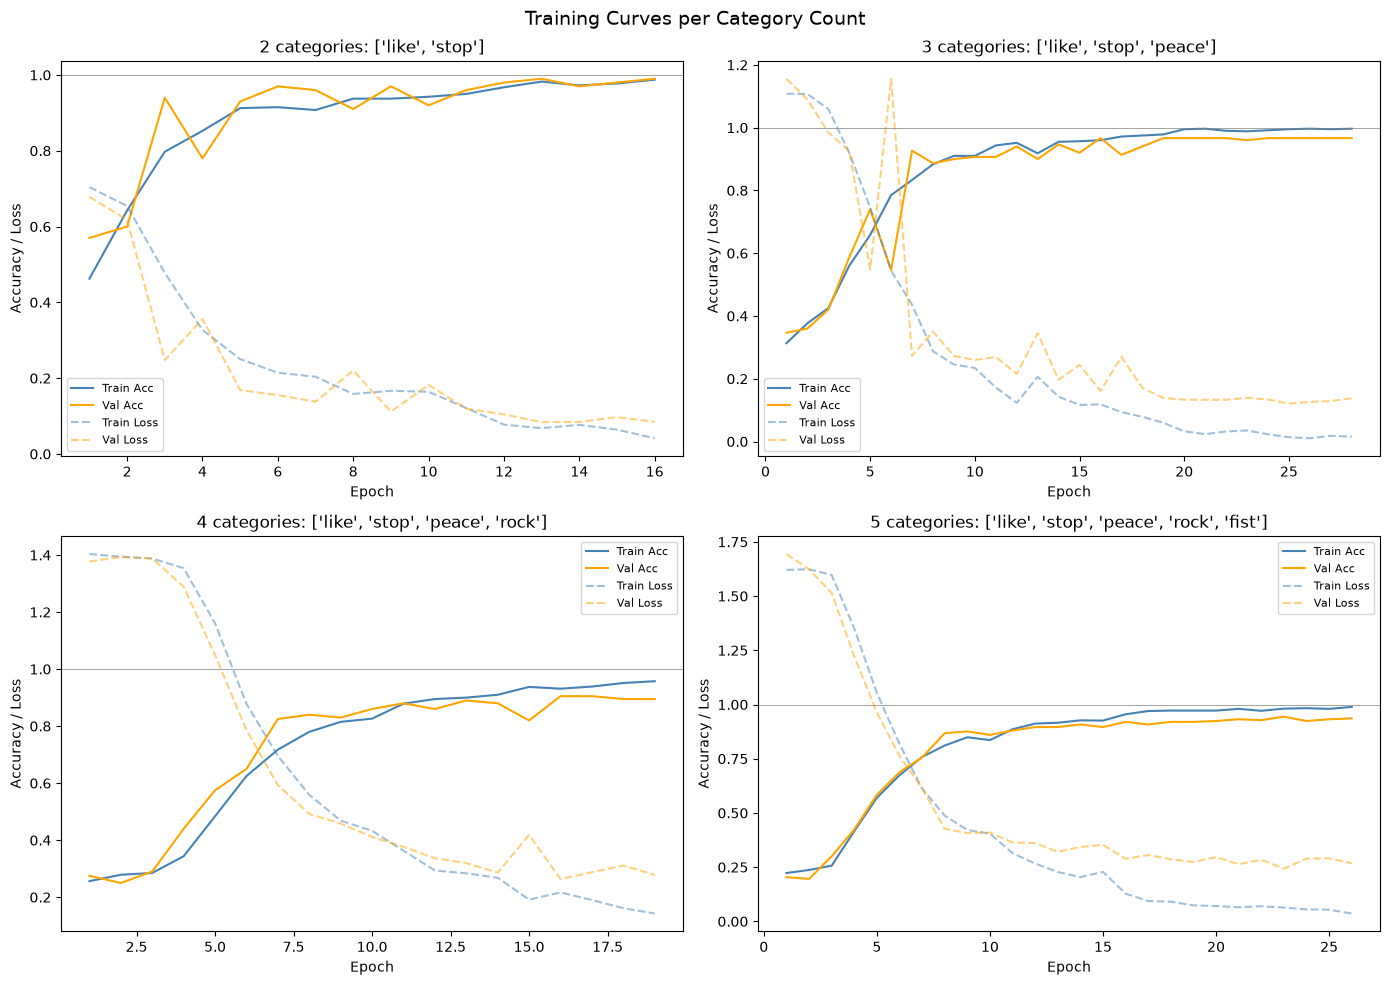

In [6]:
# Training curves for all four experiments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Curves per Category Count', fontsize=14)

colors = {'train': 'steelblue', 'val': 'orange'}

for ax, r in zip(axes.flat, results):
    h = r['history']
    ep = range(1, len(h['loss']) + 1)

    ax.plot(ep, h['accuracy'],     color=colors['train'],  label='Train Acc')
    ax.plot(ep, h['val_accuracy'], color=colors['val'],    label='Val Acc')
    ax.plot(ep, h['loss'],         color=colors['train'],  linestyle='--', alpha=0.5, label='Train Loss')
    ax.plot(ep, h['val_loss'],     color=colors['val'],    linestyle='--', alpha=0.5, label='Val Loss')

    ax.axhline(1, color='gray', linewidth=0.5)
    ax.set_title(f"{r['n_categories']} categories: {r['conditions']}")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy / Loss')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

In [7]:
# Summary table
print(f"{'Categories':>12} | {'Conditions':<40} | {'Acc':>6} | {'Inf(ms)':>8} | {'Train(s)':>9} | {'Epochs':>6}")
print('-' * 95)
for r in results:
    conds = ', '.join(r['conditions'])
    print(f"{r['n_categories']:>12} | {conds:<40} | {r['test_accuracy']:>6.4f} | "
          f"{r['inf_time_ms']:>8.2f} | {r['train_time_s']:>9.1f} | {r['epochs_trained']:>6}")

  Categories | Conditions                               |    Acc |  Inf(ms) |  Train(s) | Epochs
-----------------------------------------------------------------------------------------------
           2 | like, stop                               | 0.9900 |    30.67 |      23.2 |     16
           3 | like, stop, peace                        | 0.9667 |    31.01 |      61.3 |     28
           4 | like, stop, peace, rock                  | 0.8950 |    30.70 |      55.5 |     19
           5 | like, stop, peace, rock, fist            | 0.9360 |    32.61 |      95.9 |     26


## Findings

### Results Summary

| Categories | Conditions | Test Accuracy | Inference (ms) | Training (s) | Epochs |
|:---:|:---|:---:|:---:|:---:|:---:|
| 2 | like, stop | **99.00 %** | 30.67 | 23.2 | 16 |
| 3 | like, stop, peace | 96.67 % | 31.01 | 61.3 | 28 |
| 4 | like, stop, peace, rock | 89.50 % | 30.70 | 55.5 | 19 |
| 5 | like, stop, peace, rock, fist | 93.60 % | 32.61 | 95.9 | 26 |

---

### Accuracy
**Hypothesis partially confirmed.** Accuracy generally decreased as the number of categories increased (99 % → 90 %), but with a notable exception: the 5-category model (93.6 %) outperformed the 4-category model (89.5 %). This is likely because `fist` is visually very distinct from the other gestures (closed fist vs. open-hand signs), making it easier for the network to separate the additional class. The overall trend still supports the hypothesis that more categories increase classification difficulty.

### Inference Time
**Hypothesis confirmed.** Inference time remained essentially constant across all configurations (~30–33 ms per sample). Adding output neurons to the final Dense layer has a negligible effect on latency — the bottleneck is the convolutional backbone, which is identical in all four experiments.

### Training Time
**Hypothesis mostly confirmed.** Total training time increased from 23 s (2 categories) to 96 s (5 categories), driven primarily by the larger dataset (more images) and more training epochs needed to converge. The non-monotonic dip at 4 categories (56 s vs. 61 s for 3 categories) is explained by early stopping: the 4-category model converged faster (19 epochs) despite having more data.

### Conclusion
Increasing the number of gesture categories generally reduces classification accuracy and increases training time, while inference latency stays flat. For a real-time gesture-recognition system, the number of categories should therefore be kept to the minimum required, or a deeper/pre-trained backbone should be used to recover the accuracy lost through added class complexity.